In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install noisereduce

In [7]:
import numpy as np
import librosa
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import noisereduce as nr
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── Dataset config ──────────────────────────────────────────
DATASET_PATH   = "/content/drive/MyDrive/audio data"
CONDITION      = "Stress"
SEVERITY_LEVELS = ["high", "low", "medium"]
SAMPLE_RATE    = 22050
DURATION       = 3       # seconds per clip
N_MFCC         = 40

print("=" * 60)
print("  STRESS DETECTION  –  SVM")
print("=" * 60)
print(f"Dataset   : {DATASET_PATH}")
print(f"Condition : {CONDITION}")
print(f"Severity  : {SEVERITY_LEVELS}")
print(f"MFCC coeff: {N_MFCC}")
print(f"Features  : MFCC (mean+std) + ZCR (mean+std) + RMS (mean+std) + Pitch/F0 (mean+std)")
print("=" * 60)


  STRESS DETECTION  –  SVM
Dataset   : /content/drive/MyDrive/audio data
Condition : Stress
Severity  : ['high', 'low', 'medium']
MFCC coeff: 40
Features  : MFCC (mean+std) + ZCR (mean+std) + RMS (mean+std) + Pitch/F0 (mean+std)


In [8]:
# ── Feature extraction ──────────────────────────────────────
def extract_features(file_path, sr=SAMPLE_RATE, duration=DURATION, n_mfcc=N_MFCC):
    """
    Return feature vector for one audio file.
    Features:
      - MFCC mean + std          →  80 dims  (40 mean + 40 std)
      - Zero Crossing Rate mean + std  →   2 dims
      - RMS Energy mean + std          →   2 dims
      - Pitch / F0 mean + std          →   2 dims
    Total: 86 dimensions
    """
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration)
        audio = nr.reduce_noise(y=audio, sr=sr)

        # 1) MFCC
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std  = np.std(mfccs,  axis=1)

        # 2) Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio)
        zcr_mean = np.mean(zcr)
        zcr_std  = np.std(zcr)

        # 3) RMS Energy
        rms = librosa.feature.rms(y=audio)
        rms_mean = np.mean(rms)
        rms_std  = np.std(rms)

        # 4) Pitch (Fundamental Frequency F0) via pyin
        f0, voiced_flag, voiced_probs = librosa.pyin(
            audio, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        # Replace NaN (unvoiced) with 0 for statistics
        f0 = np.nan_to_num(f0, nan=0.0)
        f0_mean = np.mean(f0)
        f0_std  = np.std(f0)

        return np.concatenate([
            mfcc_mean, mfcc_std,            # 80
            [zcr_mean, zcr_std],             #  2
            [rms_mean, rms_std],             #  2
            [f0_mean,  f0_std]               #  2
        ])   # shape (86,)

    except Exception as e:
        print(f"  Error – {file_path}: {e}")
        return None


In [9]:
# ── Load dataset (STRESS only) ──────────────────────────────
def load_dataset(dataset_path):
    """Walk Stress severity folders, extract features, return X and y."""
    features, labels = [], []
    for severity in SEVERITY_LEVELS:
        folder = os.path.join(dataset_path, CONDITION, severity)
        if not os.path.exists(folder):
            print(f"  Warning: {folder} not found – skipping")
            continue
        label  = f"{CONDITION}_{severity}"
        files  = [f for f in os.listdir(folder)
                  if f.endswith((".wav", ".mp3", ".flac", ".ogg", ".m4a"))]
        print(f"  [{label}]  {len(files)} files")
        for i, fname in enumerate(files, 1):
            feat = extract_features(os.path.join(folder, fname))
            if feat is not None:
                features.append(feat)
                labels.append(label)
    return np.array(features), np.array(labels)

X, y = load_dataset(DATASET_PATH)
print(f"\nTotal samples : {X.shape[0]}")
print(f"Feature shape : {X.shape[1]}")
unique, counts = np.unique(y, return_counts=True)
for lbl, cnt in zip(unique, counts):
    print(f"  {lbl}: {cnt}")


  [Stress_high]  120 files
  [Stress_low]  120 files
  [Stress_medium]  120 files

Total samples : 360
Feature shape : 86
  Stress_high: 120
  Stress_low: 120
  Stress_medium: 120


In [10]:
# ── Encode  /  Split  /  Scale ──────────────────────────────

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# We split into Train and Test. GridSearchCV will handle the Validation internally.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
from sklearn.svm import SVC

# ── 5. Hyperparameter Tuning & Cross-Validation ───────────────
print("\n[INFO] Starting Hyperparameter Tuning (Grid Search)...")
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Assign the best model to our variable
svm_model = grid_search.best_estimator_


[INFO] Starting Hyperparameter Tuning (Grid Search)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8161



  EVALUATION  –  SVM (Stress)
  Test Accuracy : 0.8333  (83.33%)

  Classification Report:
               precision    recall  f1-score   support

  Stress_high       0.80      0.67      0.73        24
   Stress_low       0.81      0.92      0.86        24
Stress_medium       0.88      0.92      0.90        24

     accuracy                           0.83        72
    macro avg       0.83      0.83      0.83        72
 weighted avg       0.83      0.83      0.83        72



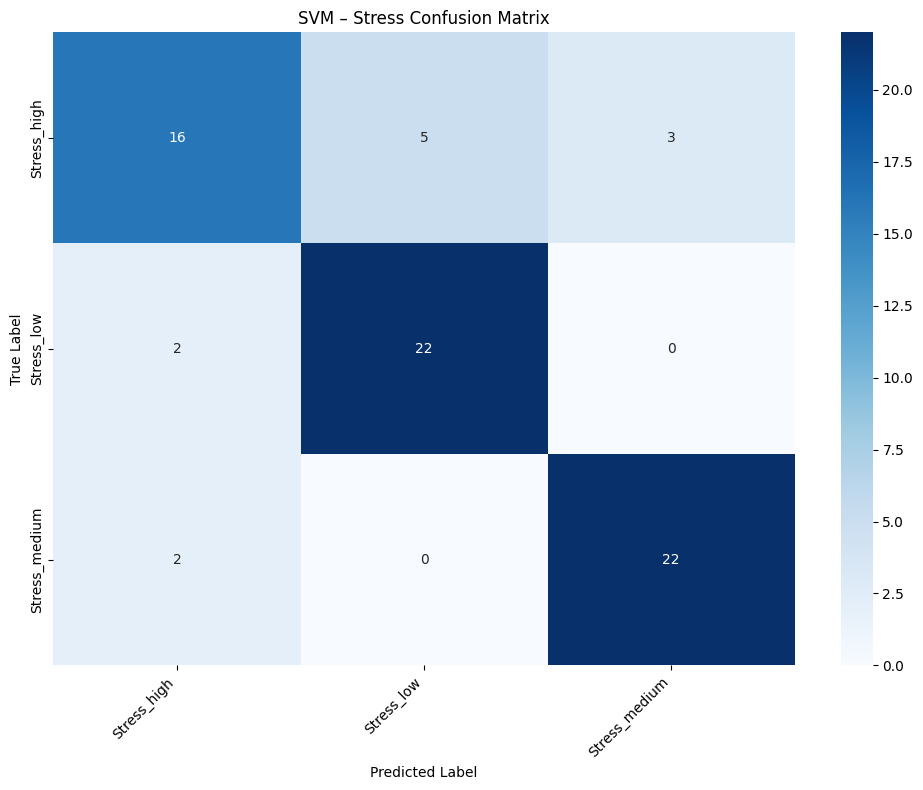

  Saved: svm_stress_confusion_matrix.png


In [ ]:
print("\n" + "="*60)
print("  EVALUATION  –  SVM (Stress)")
print("="*60)

y_pred        = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"  Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred, label_encoder.classes_,
                      "SVM – Stress Confusion Matrix", "svm_stress_confusion_matrix.png")


In [ ]:
save_artefacts(svm_model, "svm_stress_model.pkl")
print("\nDone – SVM Stress pipeline complete.")


  Saved: svm_stress_model.pkl
  Saved: stress_scaler.pkl
  Saved: stress_label_encoder.pkl

Done – SVM Stress pipeline complete.


# **kNN**

In [12]:
# ══════════════════════════════════════════════════════════════
#  K-NEAREST NEIGHBORS (KNN) – Stress
# ══════════════════════════════════════════════════════════════
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold



In [13]:

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=knn_cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {knn_grid.best_params_}")
print(f"Best CV Accuracy: {knn_grid.best_score_:.4f}")

knn_model = knn_grid.best_estimator_



Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.7809



============================== KNN TEST EVALUATION ==============================
Test Accuracy: 72.22%

Classification Report:
                precision    recall  f1-score   support

  Stress_high       0.58      0.62      0.60        24
   Stress_low       0.79      0.62      0.70        24
Stress_medium       0.81      0.92      0.86        24

     accuracy                           0.72        72
    macro avg       0.73      0.72      0.72        72
 weighted avg       0.73      0.72      0.72        72



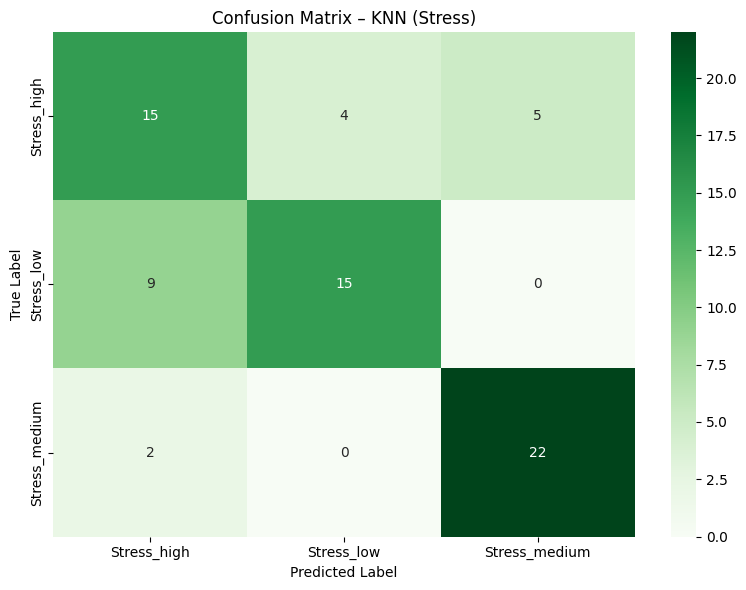

In [14]:
# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " KNN TEST EVALUATION " + "=" * 30)
y_pred_knn = knn_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d",
            cmap="Greens", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – KNN (Stress)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# **Random Forest**

In [15]:
# ══════════════════════════════════════════════════════════════
#  RANDOM FOREST – Stress (3-class)
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier


rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_param_grid,
    cv=rf_cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {rf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_



Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best CV Accuracy: 0.7914


In [16]:
# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " RANDOM FOREST TEST EVALUATION " + "=" * 30)
y_pred_rf = rf_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))




============================== RANDOM FOREST TEST EVALUATION ==============================
Test Accuracy: 76.39%

Classification Report:
                precision    recall  f1-score   support

  Stress_high       0.71      0.50      0.59        24
   Stress_low       0.74      0.83      0.78        24
Stress_medium       0.82      0.96      0.88        24

     accuracy                           0.76        72
    macro avg       0.76      0.76      0.75        72
 weighted avg       0.76      0.76      0.75        72



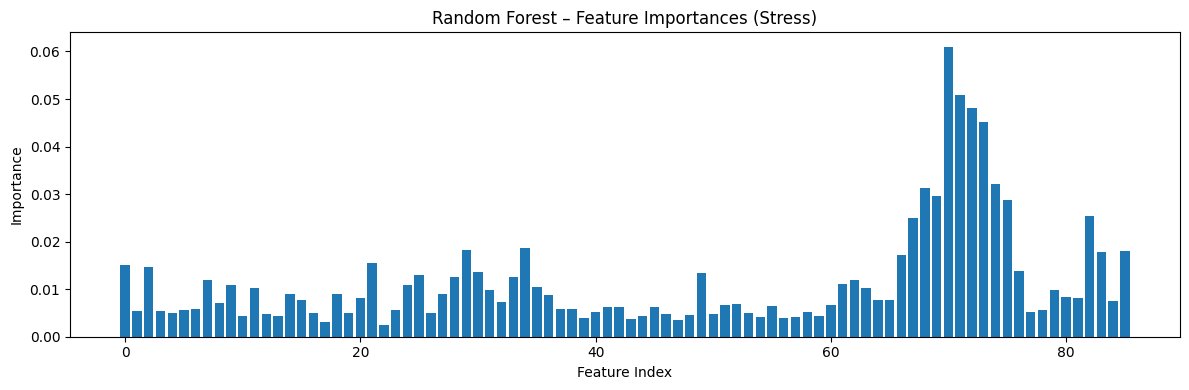

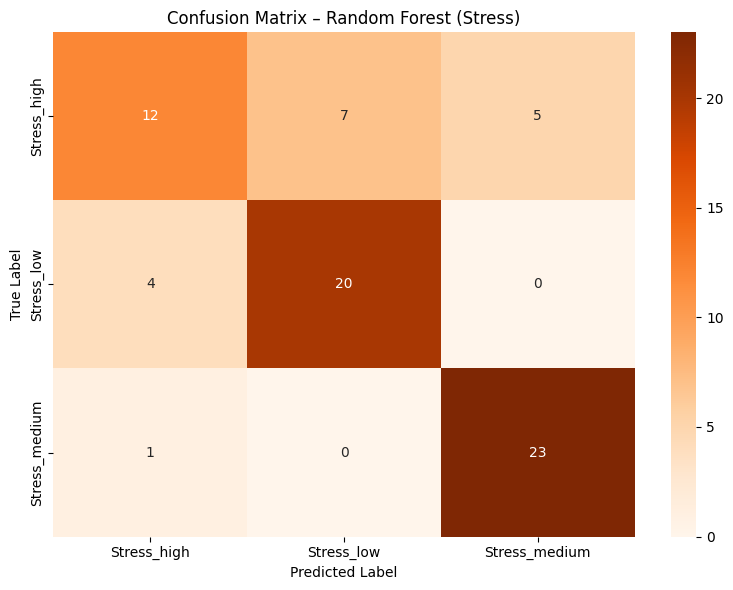

In [17]:
# Feature Importance
importances = rf_model.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest – Feature Importances (Stress)")
plt.xlabel("Feature Index"); plt.ylabel("Importance")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Oranges", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Random Forest (Stress)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# **CNN**

In [18]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import numpy as np


NUM_CLASSES = len(label_encoder.classes_)
print(f"Number of classes: {NUM_CLASSES} → {list(label_encoder.classes_)}")

# ── Class weights ─────────────────────────────────────────────
classes   = np.unique(y_train)
cw_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw_values))
print(f"Class weights: {class_weight_dict}")



Number of classes: 3 → [np.str_('Stress_high'), np.str_('Stress_low'), np.str_('Stress_medium')]
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}


In [19]:
# ── Build multiclass CNN ──────────────────────────────────────
def build_cnn_multiclass(input_dim, num_classes=3, filters=64,
                         kernel_size=3, dropout_rate=0.4,
                         learning_rate=0.001, l2_reg=1e-4):
    inp = keras.Input(shape=(input_dim, 1))

    x = layers.Conv1D(filters, kernel_size, activation='relu',
                      padding='same',
                      kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(filters * 2, kernel_size, activation='relu',
                      padding='same',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate / 2)(x)

    # Softmax output for multiclass
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',   # integer labels
        metrics=['accuracy']
    )
    return model



In [20]:
# ── Hyperparameter grid ───────────────────────────────────────
cnn_param_grid = [
    {'filters': 32,  'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001,  'l2_reg': 1e-4},
    {'filters': 64,  'kernel_size': 3, 'dropout_rate': 0.4, 'learning_rate': 0.001,  'l2_reg': 1e-4},
    {'filters': 64,  'kernel_size': 5, 'dropout_rate': 0.4, 'learning_rate': 0.0005, 'l2_reg': 1e-3},
    {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.5, 'learning_rate': 0.0005, 'l2_reg': 1e-3},
]

input_dim      = X_train.shape[1]
best_cnn_score = 0
best_cnn_params = None

for params in cnn_param_grid:
    print(f"\n[CNN] Testing: {params}")
    fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        Xf_tr,  Xf_val  = X_train[tr_idx], X_train[val_idx]
        yf_tr,  yf_val  = y_train[tr_idx], y_train[val_idx]

        Xf_tr  = Xf_tr.reshape(-1, input_dim, 1)
        Xf_val = Xf_val.reshape(-1, input_dim, 1)

        cw_fold   = compute_class_weight('balanced',
                                          classes=np.unique(yf_tr), y=yf_tr)
        cw_fold_d = dict(zip(np.unique(yf_tr), cw_fold))

        model = build_cnn_multiclass(input_dim, num_classes=NUM_CLASSES, **params)
        es  = callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                                      restore_best_weights=True, mode='max')
        rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=7, min_lr=1e-6)
        model.fit(Xf_tr, yf_tr,
                  validation_data=(Xf_val, yf_val),
                  epochs=100, batch_size=8,
                  class_weight=cw_fold_d,
                  callbacks=[es, rlr], verbose=0)

        _, val_acc = model.evaluate(Xf_val, yf_val, verbose=0)
        fold_scores.append(val_acc)
        print(f"   Fold {fold+1}: val_acc = {val_acc:.4f}")

    mean_acc = np.mean(fold_scores)
    print(f"  → Mean CV Accuracy: {mean_acc:.4f}")

    if mean_acc > best_cnn_score:
        best_cnn_score  = mean_acc
        best_cnn_params = params

print(f"\nBest CNN Params : {best_cnn_params}")
print(f"Best CV Accuracy: {best_cnn_score:.4f}")




[CNN] Testing: {'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'l2_reg': 0.0001}
   Fold 1: val_acc = 0.7241
   Fold 2: val_acc = 0.6552
   Fold 3: val_acc = 0.7414
   Fold 4: val_acc = 0.6667
   Fold 5: val_acc = 0.6667
  → Mean CV Accuracy: 0.6908

[CNN] Testing: {'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'l2_reg': 0.0001}
   Fold 1: val_acc = 0.7241
   Fold 2: val_acc = 0.7414
   Fold 3: val_acc = 0.7241
   Fold 4: val_acc = 0.6842
   Fold 5: val_acc = 0.6491
  → Mean CV Accuracy: 0.7046

[CNN] Testing: {'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.4, 'learning_rate': 0.0005, 'l2_reg': 0.001}
   Fold 1: val_acc = 0.7931
   Fold 2: val_acc = 0.7241
   Fold 3: val_acc = 0.7759
   Fold 4: val_acc = 0.7018
   Fold 5: val_acc = 0.7018
  → Mean CV Accuracy: 0.7393

[CNN] Testing: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.5, 'learning_rate': 0.0005, 'l2_reg': 0.001}
   Fold 1: val_acc = 0.7069
   Fold 2: v

In [21]:
# ── Retrain on full training set ──────────────────────────────
X_train_cnn = X_train.reshape(-1, input_dim, 1)
X_test_cnn  = X_test.reshape(-1,  input_dim, 1)

best_cnn_model = build_cnn_multiclass(input_dim, num_classes=NUM_CLASSES, **best_cnn_params)
es_final  = callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                    restore_best_weights=True, mode='max')
rlr_final = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=10, min_lr=1e-6)
history = best_cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=150, batch_size=8,
    class_weight=class_weight_dict,
    callbacks=[es_final, rlr_final], verbose=1
)



Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5035 - loss: 1.1899 - val_accuracy: 0.4444 - val_loss: 1.2770 - learning_rate: 5.0000e-04
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5486 - loss: 1.0938 - val_accuracy: 0.3333 - val_loss: 1.3018 - learning_rate: 5.0000e-04
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6007 - loss: 1.0231 - val_accuracy: 0.3333 - val_loss: 1.3017 - learning_rate: 5.0000e-04
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6389 - loss: 0.9628 - val_accuracy: 0.3472 - val_loss: 1.2700 - learning_rate: 5.0000e-04
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6632 - loss: 0.9186 - val_accuracy: 0.4722 - val_loss: 1.2317 - learning_rate: 5.0000e-04
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6806 - loss: 0.8817 - val_accuracy: 0.5417 - val_loss: 1.1725 - learning_rate: 5.0000e-04
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.65

In [22]:
# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " CNN TEST EVALUATION " + "=" * 30)
y_pred_cnn_prob = best_cnn_model.predict(X_test_cnn)   # shape (N, 3)
y_pred_cnn      = np.argmax(y_pred_cnn_prob, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_cnn) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_cnn, target_names=label_encoder.classes_))




============================== CNN TEST EVALUATION ==============================
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Test Accuracy: 73.61%

Classification Report:
                precision    recall  f1-score   support

  Stress_high       0.69      0.46      0.55        24
   Stress_low       0.73      0.79      0.76        24
Stress_medium       0.77      0.96      0.85        24

     accuracy                           0.74        72
    macro avg       0.73      0.74      0.72        72
 weighted avg       0.73      0.74      0.72        72



ROC-AUC (weighted OvR): 0.8831


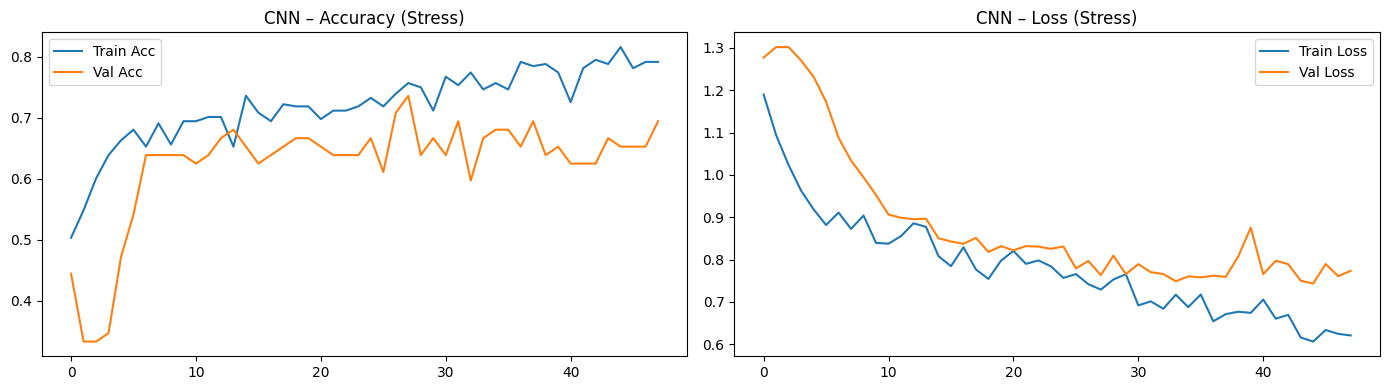

In [23]:
# Multiclass ROC-AUC (one-vs-rest)
try:
    roc_auc_cnn = roc_auc_score(y_test, y_pred_cnn_prob, multi_class='ovr', average='weighted')
    print(f"ROC-AUC (weighted OvR): {roc_auc_cnn:.4f}")
except Exception as e:
    print(f"ROC-AUC could not be computed: {e}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title("CNN – Accuracy (Stress)"); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("CNN – Loss (Stress)"); axes[1].legend()
plt.tight_layout(); plt.show()


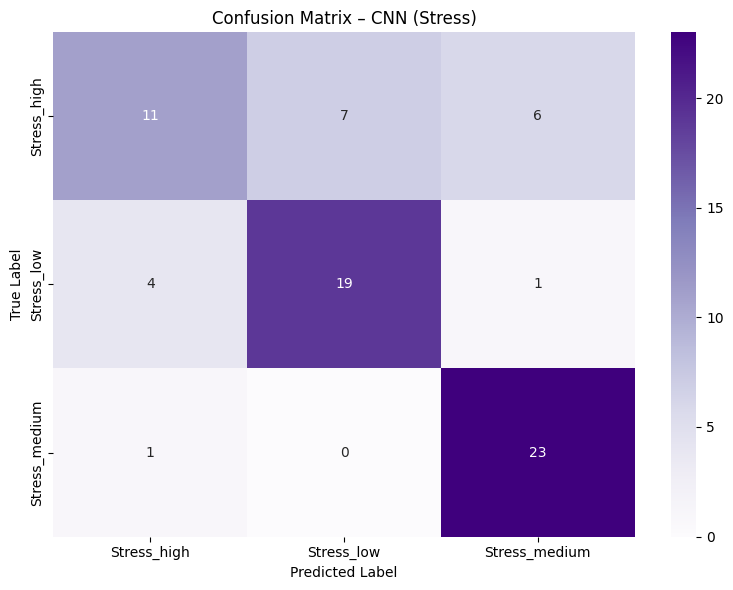

In [24]:

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt="d",
            cmap="Purples", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – CNN (Stress)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

## **Transformers**

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Transformer Block ─────────────────────────────────────────
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn   = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x, training=training)
        x    = self.norm1(x + self.drop1(attn, training=training))
        ffn  = self.ffn(x)
        return self.norm2(x + self.drop2(ffn, training=training))


def build_transformer_multiclass(input_dim, num_classes=3, embed_dim=64,
                                  num_heads=4, ff_dim=128,
                                  dropout=0.1, learning_rate=0.001):
    inp = keras.Input(shape=(input_dim,))
    x   = layers.Reshape((input_dim, 1))(inp)
    x   = layers.Dense(embed_dim)(x)

    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout / 2)(x)

    # Softmax for multiclass
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [26]:
# ── Hyperparameter grid ───────────────────────────────────────
transformer_param_grid = [
    {'embed_dim': 32,  'num_heads': 2, 'ff_dim': 64,  'dropout': 0.1,  'learning_rate': 0.001},
    {'embed_dim': 64,  'num_heads': 4, 'ff_dim': 128, 'dropout': 0.1,  'learning_rate': 0.001},
    {'embed_dim': 64,  'num_heads': 4, 'ff_dim': 128, 'dropout': 0.2,  'learning_rate': 0.0005},
    {'embed_dim': 128, 'num_heads': 8, 'ff_dim': 256, 'dropout': 0.3,  'learning_rate': 0.0005},
]

best_tr_score  = 0
best_tr_params = None
input_dim      = X_train.shape[1]

for params in transformer_param_grid:
    print(f"\n[Transformer] Testing: {params}")
    fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        Xf_tr,  Xf_val  = X_train[tr_idx], X_train[val_idx]
        yf_tr,  yf_val  = y_train[tr_idx], y_train[val_idx]

        cw_fold   = compute_class_weight('balanced',
                                          classes=np.unique(yf_tr), y=yf_tr)
        cw_fold_d = dict(zip(np.unique(yf_tr), cw_fold))

        model = build_transformer_multiclass(input_dim, num_classes=NUM_CLASSES, **params)
        es  = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                                            restore_best_weights=True, mode='max')
        rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                patience=7, min_lr=1e-6)
        model.fit(Xf_tr, yf_tr,
                  validation_data=(Xf_val, yf_val),
                  epochs=100, batch_size=8,
                  class_weight=cw_fold_d,
                  callbacks=[es, rlr], verbose=0)

        _, val_acc = model.evaluate(Xf_val, yf_val, verbose=0)
        fold_scores.append(val_acc)
        print(f"   Fold {fold+1}: val_acc = {val_acc:.4f}")

    mean_acc = np.mean(fold_scores)
    print(f"  → Mean CV Accuracy: {mean_acc:.4f}")

    if mean_acc > best_tr_score:
        best_tr_score  = mean_acc
        best_tr_params = params

print(f"\nBest Transformer Params : {best_tr_params}")
print(f"Best CV Accuracy        : {best_tr_score:.4f}")




[Transformer] Testing: {'embed_dim': 32, 'num_heads': 2, 'ff_dim': 64, 'dropout': 0.1, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.6724
   Fold 2: val_acc = 0.6897
   Fold 3: val_acc = 0.7069
   Fold 4: val_acc = 0.5439
   Fold 5: val_acc = 0.6140
  → Mean CV Accuracy: 0.6454

[Transformer] Testing: {'embed_dim': 64, 'num_heads': 4, 'ff_dim': 128, 'dropout': 0.1, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.6897
   Fold 2: val_acc = 0.6897
   Fold 3: val_acc = 0.7414
   Fold 4: val_acc = 0.5965
   Fold 5: val_acc = 0.5965
  → Mean CV Accuracy: 0.6627

[Transformer] Testing: {'embed_dim': 64, 'num_heads': 4, 'ff_dim': 128, 'dropout': 0.2, 'learning_rate': 0.0005}
   Fold 1: val_acc = 0.6552
   Fold 2: val_acc = 0.6897
   Fold 3: val_acc = 0.7069
   Fold 4: val_acc = 0.5614
   Fold 5: val_acc = 0.6140
  → Mean CV Accuracy: 0.6454

[Transformer] Testing: {'embed_dim': 128, 'num_heads': 8, 'ff_dim': 256, 'dropout': 0.3, 'learning_rate': 0.0005}
   Fold 1: val_acc = 0.7069
   Fold 2: 

In [27]:
# ── Retrain on full training set ──────────────────────────────
best_tr_model = build_transformer_multiclass(input_dim, num_classes=NUM_CLASSES, **best_tr_params)
es_final  = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                          restore_best_weights=True, mode='max')
rlr_final = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                              patience=10, min_lr=1e-6)
tr_history = best_tr_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150, batch_size=8,
    class_weight=class_weight_dict,
    callbacks=[es_final, rlr_final], verbose=1
)



Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5556 - loss: 0.9658 - val_accuracy: 0.5556 - val_loss: 0.9307 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5278 - loss: 0.9200 - val_accuracy: 0.6111 - val_loss: 0.8751 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5069 - loss: 0.9293 - val_accuracy: 0.6111 - val_loss: 0.8911 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5694 - loss: 0.8722 - val_accuracy: 0.6667 - val_loss: 0.8418 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5625 - loss: 0.8874 - val_accuracy: 0.5556 - val_loss: 0.9364 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5938 - loss: 0.8805 - val_accuracy: 0.5833 - val_loss: 0.8381 - learning_rate: 0.0010
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5938 - loss: 0.8668 - 

In [28]:
# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " TRANSFORMER TEST EVALUATION " + "=" * 30)
y_pred_tr_prob = best_tr_model.predict(X_test)         # shape (N, 3)
y_pred_tr      = np.argmax(y_pred_tr_prob, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tr) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_tr, target_names=label_encoder.classes_))

try:
    roc_auc_tr = roc_auc_score(y_test, y_pred_tr_prob, multi_class='ovr', average='weighted')
    print(f"ROC-AUC (weighted OvR): {roc_auc_tr:.4f}")
except Exception as e:
    print(f"ROC-AUC could not be computed: {e}")






============================== TRANSFORMER TEST EVALUATION ==============================
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
Test Accuracy: 66.67%

Classification Report:
                precision    recall  f1-score   support

  Stress_high       0.80      0.33      0.47        24
   Stress_low       0.73      0.67      0.70        24
Stress_medium       0.60      1.00      0.75        24

     accuracy                           0.67        72
    macro avg       0.71      0.67      0.64        72
 weighted avg       0.71      0.67      0.64        72

ROC-AUC (weighted OvR): 0.7743


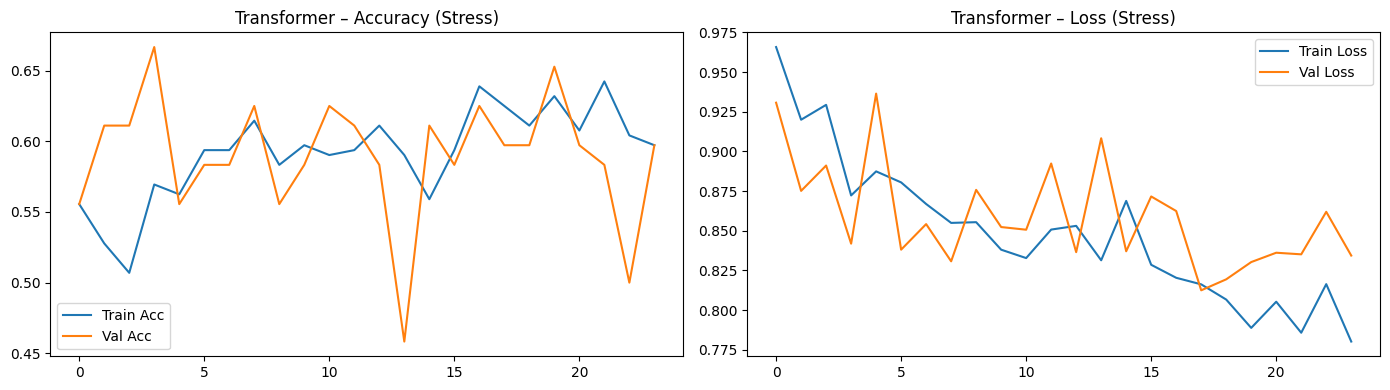

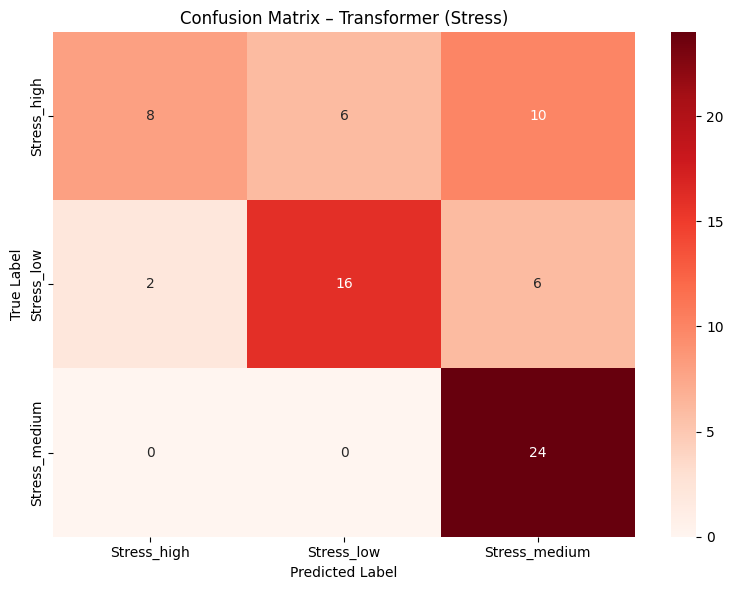

In [29]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(tr_history.history['accuracy'],     label='Train Acc')
axes[0].plot(tr_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title("Transformer – Accuracy (Stress)"); axes[0].legend()
axes[1].plot(tr_history.history['loss'],     label='Train Loss')
axes[1].plot(tr_history.history['val_loss'], label='Val Loss')
axes[1].set_title("Transformer – Loss (Stress)"); axes[1].legend()
plt.tight_layout(); plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_tr), annot=True, fmt="d",
            cmap="Reds", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Transformer (Stress)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()